# Tutorial 10: Calculation Settings

This tutorial demonstrates how to change the calculation type, time frame, thermal settings, and working directory. In addition the manual editing of the XML-Calculation file will be demonstrated. This allows to configure different calculations for one model and seperate them into different directories.

## SIR 3S Installation

In [1]:
SIR3S_SIRGRAF_DIR = r"C:\3S\SIR 3S\SirGraf-90-15-00-24_Quebec-Upd2" #change to local path

## Imports

Note: The SIR 3S Toolkit requires the Sir3S_Toolkit.dll included in SIR 3S installations (version Quebec and higher).

In [2]:
import sir3stoolkit

The core of sir3stoolkit is a Python wrapper around basic functionality of SIR 3S, offering a low-level access to the creation, modification and simulation of SIR 3S models. In the future pure python subpackages may be added.

In [3]:
from sir3stoolkit.core import wrapper

In [4]:
sir3stoolkit

<module 'sir3stoolkit' from 'C:\\Users\\aUsername\\3S\\sir3stoolkit\\src\\sir3stoolkit\\__init__.py'>

The [wrapper package](https://3sconsult.github.io/sir3stoolkit/references/sir3stoolkit.core.html#sir3stoolkit.core.wrapper.Initialize_Toolkit) has to be initialized with reference to a SIR 3S (SIR Graf) installation.

In [5]:
wrapper.Initialize_Toolkit(SIR3S_SIRGRAF_DIR)

[2026-08-28 14:38:39,310] INFO in sir3stoolkit.core.wrapper: [Initialization] Using provided SirGraf path: C:\3S\SIR 3S\SirGraf-90-15-00-24_Quebec-Upd2
[2026-08-28 14:38:39,310] INFO in sir3stoolkit.core.wrapper: [Initialization] Using provided SirGraf path: C:\3S\SIR 3S\SirGraf-90-15-00-24_Quebec-Upd2
[2026-08-28 14:38:39,444] INFO in sir3stoolkit.core.wrapper: [Initialization] Initializing toolkit with SirGraf path: C:\3S\SIR 3S\SirGraf-90-15-00-24_Quebec-Upd2


## Initialization

The SIR 3S Toolkit contains two classes: [SIR3S_Model](https://3sconsult.github.io/sir3stoolkit/references/sir3stoolkit.core.html#sir3stoolkit.core.wrapper.SIR3S_Model) (model and data) and [SIR3S_View](https://3sconsult.github.io/sir3stoolkit/references/sir3stoolkit.core.html#sir3stoolkit.core.wrapper.SIR3S_View) (depiction in SIR Graf). All SIR 3S Toolkit functionality is accessed via the methods of these classes.

In [6]:
s3s = wrapper.SIR3S_Model()

[2026-08-28 14:38:40,957] INFO in sir3stoolkit.core.wrapper: [Model Class Initialization] Initialization complete


## Open Model

In [7]:
s3s.OpenModel(dbName=r"Toolkit_Tutorial10_Model.db3", 
              providerType=s3s.ProviderTypes.SQLite, 
              Mid="M-1-0-1", 
              saveCurrentlyOpenModel=False, 
              namedInstance="", 
              userID="", 
              password="")

[2026-08-28 14:38:53,035] INFO in sir3stoolkit.core.wrapper: Model is open for further operation


Now the model has been opened. All SIR 3S Toolkit operations now apply to this model until another one is opened.

In [8]:
print(s3s.GetNetworkType()) # to check that the correct model is responsive, model we are trying to open was created with type Water

NetworkType.Water


# GetDBSourcePath()

We can use the method [GetDBSourcePath()](https://3sconsult.github.io/sir3stoolkit/modules.html#sir3stoolkit.core.wrapper.SIR3S_Model.GetDBSourcePath) to retrieve basic information regarding the db file. We get a tuple of four strings as a return.

In [9]:
(dbPath, connectionString, dbVendor, dbName) = s3s.GetDBSourcePath()

In [10]:
dbPath

'Toolkit_Tutorial10_Model.db3'

In [11]:
connectionString

'provider=System.Data.SQLite;data source="Toolkit_Tutorial10_Model.db3";version=3'

In [12]:
dbVendor

'SQLite'

In [13]:
dbName

'Toolkit_Tutorial10_Model'

# GetWorkingDirectory()

The working directory of SIR 3S holds its calculation results.

We can use the method [GetWorkingDirectory()](https://3sconsult.github.io/sir3stoolkit/modules.html#sir3stoolkit.core.wrapper.SIR3S_Model.GetWorkingDirectory) to get the currently used working directory currently assigned to the model.

In [14]:
working_directory_1 = s3s.GetWorkingDirectory()

In [15]:
print(working_directory_1)

c:\Users\aUsername\3S\sir3stoolkit\docs\source\tutorials\SIR3S_Model\Tutorial010_Assets\WDToolkit_Tutorial10_Model_1


# AllocateWorkingDirectory()

We can use the method [AllocateWorkingDirectory()](https://3sconsult.github.io/sir3stoolkit/modules.html#sir3stoolkit.core.wrapper.SIR3S_Model.AllocateWorkingDirectory) to change the working directory of the model to a different directory. The basic file structure needed to hold SIR 3S calculation results will be created automatically (if it does not exist already). This must be a valid, existing, writable and readable Directory Path.

In [16]:
working_directory_2 = r"C:\Users\Jabonski\3S\sir3stoolkit\docs\source\tutorials\SIR3S_Model\Tutorial010_Assets\WDToolkit_Tutorial10_Model_2"

In [17]:
s3s.AllocateWorkingDirectory(strDirectory=working_directory_2)

Error: The specified directory 'C:\Users\Jabonski\3S\sir3stoolkit\docs\source\tutorials\SIR3S_Model\Tutorial010_Assets\WDToolkit_Tutorial10_Model_2' does not exist.


False

In [18]:
print(s3s.GetWorkingDirectory())

c:\Users\aUsername\3S\sir3stoolkit\docs\source\tutorials\SIR3S_Model\Tutorial010_Assets\WDToolkit_Tutorial10_Model_1


# CreateWorkingDirectory()

We can use the method [CreateWorkingDirectory()](https://3sconsult.github.io/sir3stoolkit/modules.html#sir3stoolkit.core.wrapper.SIR3S_Model.CreateWorkingDirectory) to create a SIR 3S working directory and assign it to the currently open model via Toolkit. The param strDirectory is the parent dir, where the new working dir should be created. It will take the standard working dir name 'WD{Model_Name}'.

In [19]:
working_directory_new_parent = r"C:\Users\aUsername\3S\sir3stoolkit\docs\source\tutorials\SIR3S_Model\Tutorial010_Assets"

In [20]:
s3s.CreateWorkingDirectory(strDirectory=working_directory_new_parent)

True

In [21]:
print(s3s.GetWorkingDirectory())

C:\Users\aUsername\3S\sir3stoolkit\docs\source\tutorials\SIR3S_Model\Tutorial010_Assets\WDToolkit_Tutorial10_Model


# GetCalculationType()

We can use the method GetCalculationType() to check, what calculation type is currently set for a model.

In [22]:
calculation_type = s3s.GetCalculationType()

In [23]:
print(calculation_type)

LowFreq


# SetCalculationType()

We can use the method [SetCalculationType()](https://3sconsult.github.io/sir3stoolkit/modules.html#sir3stoolkit.core.wrapper.SIR3S_Model.SetCalculationType) to change between different calculation types. The types are saved in python enum, and have to be accessed via this enum.

In [24]:
CalculationType = [item for item in dir(s3s.CalculationType) if not (item.startswith('__') and item.endswith('__'))]
print(CalculationType)

['HighFreq_AUTO', 'HighFreq_CHAR', 'Instat_FiniteDiff', 'LoopForLoadingCondition', 'LowFreq', 'Quasi_Stat', 'SteadyState', 'Unknown']


Not every calculation type is applicable to every network type (s3s.NetworkType). See main SIR 3S manual for details.

For Water and DH networks. Only SteadyState | Quasi_Stat | LowFreq | HighFreq_CHAR | HighFreq_AUTO | LoopForLoadingCondition are valid

For Gas/Steam Networks, only SteadyState | Quasi_Stat | HighFreq_CHAR | Instat_FiniteDiff | LoopForLoadingCondition are valid

Let's set this model to "high-frequency automatic" calculations.

In [25]:
s3s.SetCalculationType(s3s.CalculationType.HighFreq_AUTO)

True

In [26]:
print(s3s.GetCalculationType())

HighFreq_AUTO


# Adjust stationary time stamp

In [27]:
print(f"Current Stationary Timestamp: {s3s.GetValue(Tk=s3s.GetTksofElementType(s3s.ObjectTypes.GeneralSection)[0], propertyName='bz.Cdat')[0]}, {s3s.GetValue(Tk=s3s.GetTksofElementType(s3s.ObjectTypes.GeneralSection)[0], propertyName='bz.CUhr')[0]}")

Current Stationary Timestamp: 29.04.2026, 14:10:00


In [28]:
s3s.SetValue(Tk=s3s.GetTksofElementType(s3s.ObjectTypes.GeneralSection)[0], propertyName="bz.Cdat", Value="01.03.2026")

[2026-08-28 14:38:54,869] INFO in sir3stoolkit.core.wrapper: Value is set


In [29]:
s3s.SetValue(Tk=s3s.GetTksofElementType(s3s.ObjectTypes.GeneralSection)[0], propertyName="bz.CUhr", Value="12:00:00")

[2026-08-28 14:38:54,943] INFO in sir3stoolkit.core.wrapper: Value is set


In [30]:
print(f"Adjusted Stationary Timestamp: {s3s.GetValue(Tk=s3s.GetTksofElementType(s3s.ObjectTypes.GeneralSection)[0], propertyName='bz.Cdat')[0]}, {s3s.GetValue(Tk=s3s.GetTksofElementType(s3s.ObjectTypes.GeneralSection)[0], propertyName='bz.CUhr')[0]}")

Adjusted Stationary Timestamp: 01.03.2026, 12:00:00


# GetSimulationTimeFrame()

We can use the method [GetSimulationTimeFrame()](https://3sconsult.github.io/sir3stoolkit/modules.html#sir3stoolkit.core.wrapper.SIR3S_Model.GetSimulationTimeFrame) to check the time frame of the model.

In [31]:
print(s3s.GetSimulationTimeFrame())

(6.0, 1200.0)


We get such a tuple: (increment, end time) both in seconds

# SetSimulationTimeFrame()

After setting the stationary timestamp we can use the method [SetSimulationTimeFrame()](https://3sconsult.github.io/sir3stoolkit/modules.html#sir3stoolkit.core.wrapper.SIR3S_Model.SetSimulationTimeFrame) to set time stamp increment and end time for the simulation (both in seconds).

In [32]:
s3s.SetSimulationTimeFrame(timeStep=30.0, terminationTime=3600.0) # We increment 30s until we reach 3600s (1 hour) for the simulation. 

In [33]:
print(s3s.GetSimulationTimeFrame())

(30.0, 3600.0)


# GetThermalCalculationParemeters()

We can use the method [GetThermalCalculationParemeters()](https://3sconsult.github.io/sir3stoolkit/modules.html#sir3stoolkit.core.wrapper.SIR3S_Model.GetThermalCalculationParemeters) to determine how the thermal calculation parameters are currently set.

In [34]:
thermal_params = s3s.GetThermalCalculationParemeters()

We get such a tuple: (activateThermalcalculation, startWithTempField, terminationPrecision, transientThermalcalculation) 

In [35]:
thermal_params[0] # activateThermalcalculation

False

In [36]:
thermal_params[1] # startWithTempField

False

In [37]:
thermal_params[2] # terminationPrecision

0.10000000149011612

In [38]:
thermal_params[3] # transientThermalcalculation

False

# SetThermalCalculationParemeters()

We can use the method [SetThermalCalculationParemeters()](https://3sconsult.github.io/sir3stoolkit/modules.html#sir3stoolkit.core.wrapper.SIR3S_Model.SetThermalCalculationParemeters) to adjust the thermal calculation parameters.

In [39]:
s3s.SetThermalCalculationParemeters(activateThermalcalculation=True
                                    ,startWithTempField=True
                                    ,terminationPrecision=0.05
                                    ,transientThermalcalculation=True) # This Parameter only has effect on High Frequency AUTO Calculation, HF CHAR Calculation and Low Freq. Calculation on Water and DH Networks. For more Precisions, please refer to the SirCalc Documentation.

In [40]:
thermal_params = s3s.GetThermalCalculationParemeters()

We get such a tuple: (activateThermalcalculation, startWithTempField, terminationPrecision, transientThermalcalculation) 

In [41]:
thermal_params[0] # activateThermalcalculation

True

In [42]:
thermal_params[1] # startWithTempField

True

In [43]:
thermal_params[2] # terminationPrecision

0.05000000074505806

In [44]:
thermal_params[3] # transientThermalcalculation

True

# 1st Calculation

In [45]:
s3s.AllocateWorkingDirectory(strDirectory=working_directory_1)

True

Make sure to save the changes before calculating.

In [46]:
s3s.SaveChanges()

[2026-08-28 14:39:05,218] INFO in sir3stoolkit.core.wrapper: Changes saved successfully


We use the [ExecCalculation()](https://3sconsult.github.io/sir3stoolkit/references/sir3stoolkit.core.html#sir3stoolkit.core.wrapper.SIR3S_Model.ExecCalculation) function to trigger a new Calculation of the SIR 3S Model using SIR Calc (version that is specfied in the components of the SIR Graf, that was used to initialize the Toolkit).

In [47]:
s3s.ExecCalculation(waitForSirCalcToExit=True)

[2026-08-28 14:39:13,735] INFO in sir3stoolkit.core.wrapper: Model Calculation is complete


We can check the status of the calculation

In [48]:
Exit_status = s3s.GetResultValue(s3s.GetTksofElementType(s3s.ObjectTypes.GeneralSection)[0],"EXSTAT")[0]

In [49]:
print(Exit_status)

0


German Interpretation:
- -1=undefiniert
- 0=normal
- 1=Benutzerabbruch
- 2=fragwürdige Ergebnisse
- 3=schlechte oder ungültige Ergebnisse
- 100=Ergebnisse halten für Analyse
- 101=Stopp-Signal für Analyse

English Interpretation:
- -1=undefined
- 0=normal
- 1=user-interrupt
- 2=questionable results
- 3=bad or invald result
- 100=holding results for analysis
- 101=stop-signal for analysis

Our results are normal.

Let's look at the pressure of a singular node to later compare it with another calculation.

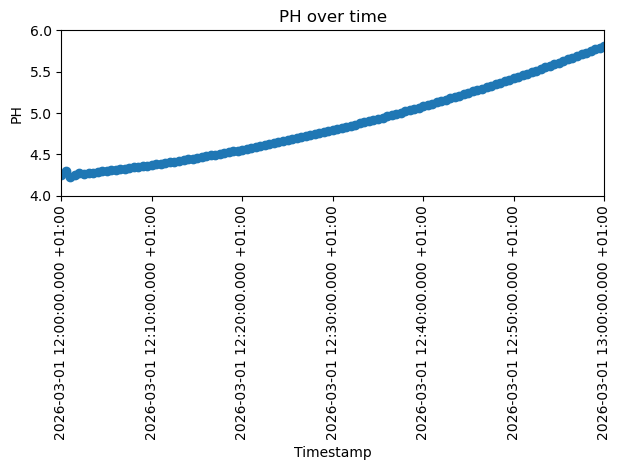

In [50]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

timestamps = s3s.GetTimeStamps()[0]
values_1 = [float(s3s.GetResultfortimestamp(Tk="4769939796812007971", property="PH", timestamp=t)[0]) for t in timestamps]

plt.plot(timestamps, values_1, marker="o")
plt.ylim(4, 6)
plt.xlim(0, len(timestamps) - 1)
plt.xticks(rotation=90)
plt.xlabel("Timestamp")
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=7))
plt.ylabel("PH")
plt.title("PH over time")
plt.tight_layout()
plt.show()

# WriteSirCalcXmlFile()

The method [WriteSirCalcXmlFile()](https://3sconsult.github.io/sir3stoolkit/modules.html#sir3stoolkit.core.wrapper.SIR3S_Model.WriteSirCalcXmlFile) will write XML calculation file and mx1 file based on the current SIR 3S model.

When running [ExecCalculation()](https://3sconsult.github.io/sir3stoolkit/references/sir3stoolkit.core.html#sir3stoolkit.core.wrapper.SIR3S_Model.ExecCalculation) these files will be created and the sent to SirCalc.exe to run the simulation. But now we have the files without instantly running a simulation with them. We can instead manually edit the XML calculation file and later on manually sent it to SirCalc.exe for the simulation.

You should only manually edit these files, if you know what you are doing. Otherwise your calculation configuration could become deprecated. If you mess up, you can reset to the current SIR 3S model state by reexecuting [WriteSirCalcXmlFile()](https://3sconsult.github.io/sir3stoolkit/modules.html#sir3stoolkit.core.wrapper.SIR3S_Model.WriteSirCalcXmlFile).

In [51]:
xml_path = s3s.WriteSirCalcXmlFile(saveItInThisDirectory=working_directory_1)

In [52]:
print(xml_path)

c:\Users\aUsername\3S\sir3stoolkit\docs\source\tutorials\SIR3S_Model\Tutorial010_Assets\WDToolkit_Tutorial10_Model_1\B1\V0\BZ1\M-1-0-1.XML


# Edit XML File

Now we can make any kind of change to the XML-File which mainly contains table values.

We now perform some silly XML edit by flipping the rpm values from rising to sinking over time. This is just for demonstration, not a realistic edit.

In [53]:
import re
import xml.etree.ElementTree as ET

def flip_pumd_rowt_n(xml_file, pumd_fk):
    with open(xml_file, encoding="Windows-1252") as f:
        text = f.read()

    row_pattern = re.compile(
        r'<PUMD_ROWT\b[^>]*\bfk="{}"[^>]*/>'.format(re.escape(pumd_fk))
    )
    rows = row_pattern.findall(text)

    def get_attr(tag, name):
        return re.search(r'{}="([^"]*)"'.format(name), tag).group(1)

    rows_sorted = sorted(rows, key=lambda tag: float(get_attr(tag, "ZEIT")))
    n_values = [get_attr(tag, "N") for tag in rows_sorted]
    n_values_flipped = list(reversed(n_values))

    for tag, new_n in zip(rows_sorted, n_values_flipped):
        old_n = get_attr(tag, "N")
        new_tag = re.sub(r'N="{}"'.format(re.escape(old_n)), 'N="{}"'.format(new_n), tag)
        text = text.replace(tag, new_tag)

    with open(xml_file, "w", encoding="Windows-1252") as f:
        f.write(text)

In [54]:
flip_pumd_rowt_n(xml_path, pumd_fk="4778790377408093653")

# 2cd Calculation

Now let's calculate with our changed XML File.

We need to provide the path to the SirCalc.exe we want to use.

In [55]:
SIRCALCDIR = r"C:\3S\SIR 3S\SirCalc-90-15-02-46_Quebec.fix7\SirCalc.exe"

In [56]:
import subprocess

with subprocess.Popen([SIRCALCDIR, xml_path]) as process:
        process.wait()
        print(f'Command {process.args} exited with {process.returncode}.')

Command ['C:\\3S\\SIR 3S\\SirCalc-90-15-02-46_Quebec.fix7\\SirCalc.exe', 'c:\\Users\\aUsername\\3S\\sir3stoolkit\\docs\\source\\tutorials\\SIR3S_Model\\Tutorial010_Assets\\WDToolkit_Tutorial10_Model_1\\B1\\V0\\BZ1\\M-1-0-1.XML'] exited with 0.


Important Notice: When calculating this way, the mx results are not properly attached to the SIR3S_Model(), if we want to read the results via Toolkit and not directly via the mx-files, we need to reopen the model. We are working on a better solution for this, that does not require to reopen the model.

In [57]:
s3s.CloseModel(False)

True

In [58]:
s3s.OpenModel(dbName=r"Toolkit_Tutorial10_Model.db3", 
              providerType=s3s.ProviderTypes.SQLite, 
              Mid="M-1-0-1", 
              saveCurrentlyOpenModel=False, 
              namedInstance="", 
              userID="", 
              password="")

[2026-08-28 14:39:29,972] INFO in sir3stoolkit.core.wrapper: Model is open for further operation


We can check the status of the calculation

In [59]:
Exit_status = s3s.GetResultValue(s3s.GetTksofElementType(s3s.ObjectTypes.GeneralSection)[0],"EXSTAT")[0]

In [60]:
print(Exit_status)

0


German Interpretation:
- -1=undefiniert
- 0=normal
- 1=Benutzerabbruch
- 2=fragwürdige Ergebnisse
- 3=schlechte oder ungültige Ergebnisse
- 100=Ergebnisse halten für Analyse
- 101=Stopp-Signal für Analyse

English Interpretation:
- -1=undefined
- 0=normal
- 1=user-interrupt
- 2=questionable results
- 3=bad or invald result
- 100=holding results for analysis
- 101=stop-signal for analysis

Our results are normal.

Let's look at the pressure of a singular node and compare it to the previous calculation.

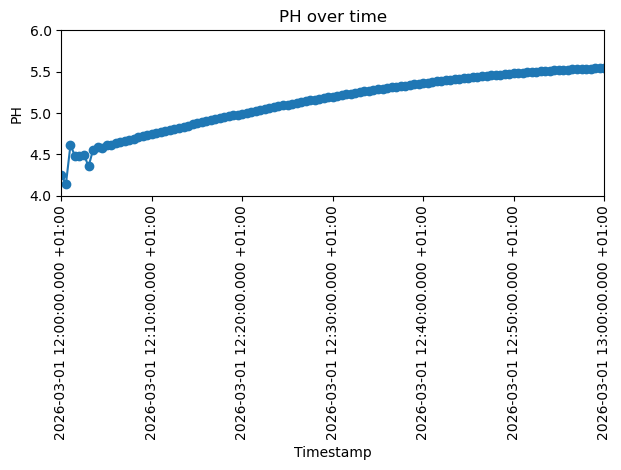

In [61]:
timestamps = s3s.GetTimeStamps()[0]
values_2 = [float(s3s.GetResultfortimestamp(Tk="4769939796812007971", property="PH", timestamp=t)[0]) for t in timestamps]

plt.plot(timestamps, values_2, marker="o")
plt.ylim(4, 6)
plt.xlim(0, len(timestamps) - 1)
plt.xticks(rotation=90)
plt.xlabel("Timestamp")
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=7))
plt.ylabel("PH")
plt.title("PH over time")
plt.tight_layout()
plt.show()

Below we see the first calculation as a comparison.

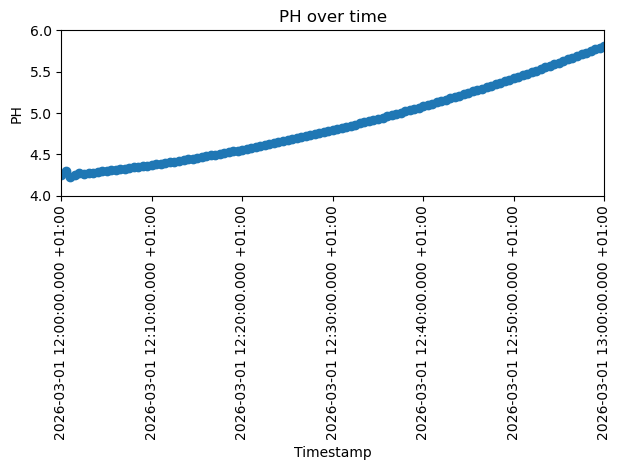

In [62]:
plt.plot(timestamps, values_1, marker="o")
plt.ylim(4, 6)
plt.xlim(0, len(timestamps) - 1)
plt.xticks(rotation=90)
plt.xlabel("Timestamp")
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=7))
plt.ylabel("PH")
plt.title("PH over time")
plt.tight_layout()
plt.show()

Important Notice: Currently when calling the calculation 

# CopyWorkingDirectory()

We can use the method [CopyWorkingDirectory()](https://3sconsult.github.io/sir3stoolkit/modules.html#sir3stoolkit.core.wrapper.SIR3S_Model.CopyWorkingDirectory) to copy the contents and therefore the results of our current working dir to another path. This way we can save a XML calculation configuration and attached results and can continue on our main working dir with another configuration.

In [63]:
config_a_path = r"C:\Users\aUsername\3S\sir3stoolkit\docs\source\tutorials\SIR3S_Model\Tutorial010_Assets\configs\config_a"

In [64]:
s3s.CopyWorkingDirectory(strDestinationDirectory=config_a_path)

Error: An error occurred while creating the Subdirectory 'C:\Users\aUsername\3S\sir3stoolkit\docs\source\tutorials\SIR3S_Model\Tutorial010_Assets\configs\config_a': Der Zugriff auf den Pfad "C:\Users\aUsername\3S\sir3stoolkit\docs\source\tutorials\SIR3S_Model\Tutorial010_Assets\configs\config_a" wurde verweigert.


False

In [65]:
s3s.SaveChanges()

[2026-08-28 14:39:38,927] INFO in sir3stoolkit.core.wrapper: Changes saved successfully
